Name : Aishi De
PRN : 23070521008
Sem : 7
Sec : A
Batch : A1

Deep Feed Forward Network for Classification
Breast Cancer Dataset

AIM :
Classification using Deep Feed Forward Network. Problem Statement: Build a deep neural
network classifier using a Kaggle dataset such as Customer Churn, Bank Marketing, or Breast
Cancer dataset. Activities: Data preprocessing; Model training and testing; Analyze confusion
matrix and accuracy

In [24]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
# Load Breast Cancer Dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Number of Features:", X.shape[1])
print("Class Names:", data.target_names)

Dataset Shape: (569, 30)
Number of Features: 30
Class Names: ['malignant' 'benign']


In [26]:
# Data Preprocessing
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


Training Samples: 455
Testing Samples: 114


In [27]:
# Build the Deep Feed Forward Neural Network

model = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(64, activation='relu'),
    Dropout(0.25),

    Dense(32, activation='relu'),
    Dropout(0.20),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [30]:
# Early stopping prevents unnecessary training and overfitting

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,

    validation_split=0.20,

    epochs=40,
    batch_size=16,

    callbacks=[early_stopping],

    verbose=1
)

Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7445 - loss: 0.5916 - val_accuracy: 0.9341 - val_loss: 0.4500
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9231 - loss: 0.3734 - val_accuracy: 0.9451 - val_loss: 0.2590
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9313 - loss: 0.2268 - val_accuracy: 0.9560 - val_loss: 0.1592
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9533 - loss: 0.1548 - val_accuracy: 0.9560 - val_loss: 0.1169
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9560 - loss: 0.1301 - val_accuracy: 0.9670 - val_loss: 0.0858
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9725 - loss: 0.1096 - val_accuracy: 0.9780 - val_loss: 0.0675
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9780 - loss: 0.0893 - val_accuracy: 0.9890 - val_loss: 0.0565
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9780 - loss: 0.0834 - val_accuracy: 0.9890 - val_lo

In [32]:
# Evaluate the Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

MODEL PERFORMANCE
Test Loss     : 0.1215
Test Accuracy : 97.37%


In [33]:
# Make Predictions
# Predict probabilities
y_probability = model.predict(X_test)

# Convert probabilities into class labels
y_pred = (y_probability > 0.5).astype(int).ravel()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [34]:
# Accuracy and Classification Report
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:")
print(f"{accuracy * 100:.2f}%")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

Accuracy Score:
97.37%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion Matrix:
[[41  1]
 [ 2 70]]


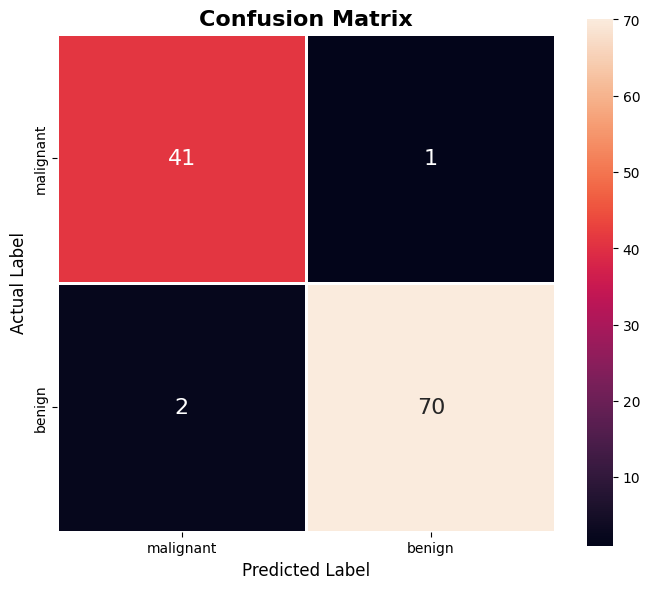

In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    linewidths=1,
    square=True,
    xticklabels=data.target_names,
    yticklabels=data.target_names,
    annot_kws={"size": 16}
)

plt.title(
    'Confusion Matrix',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

plt.tight_layout()
plt.show()

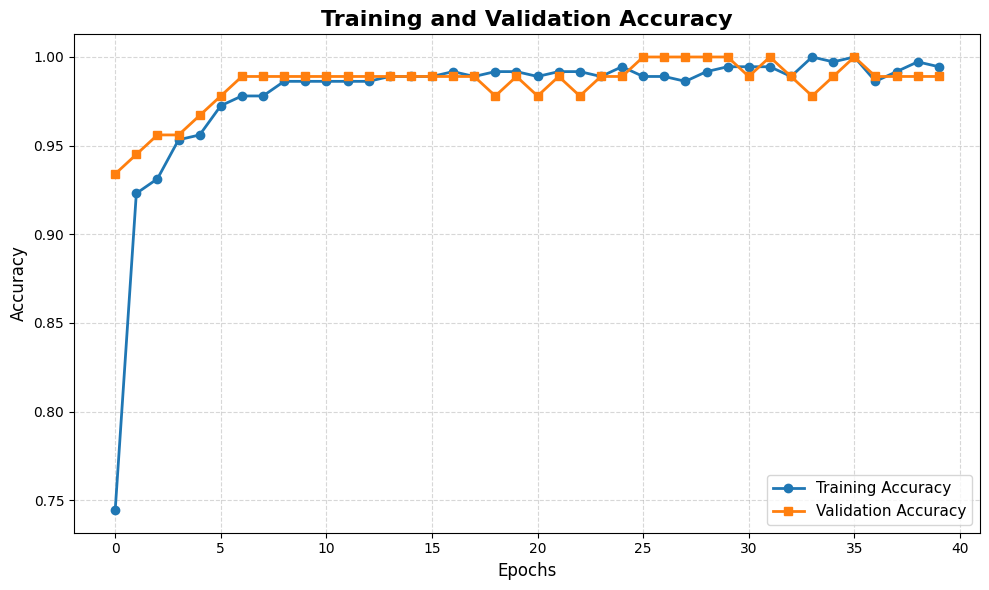

In [36]:
# Accuracy Graph
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title(
    'Training and Validation Accuracy',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

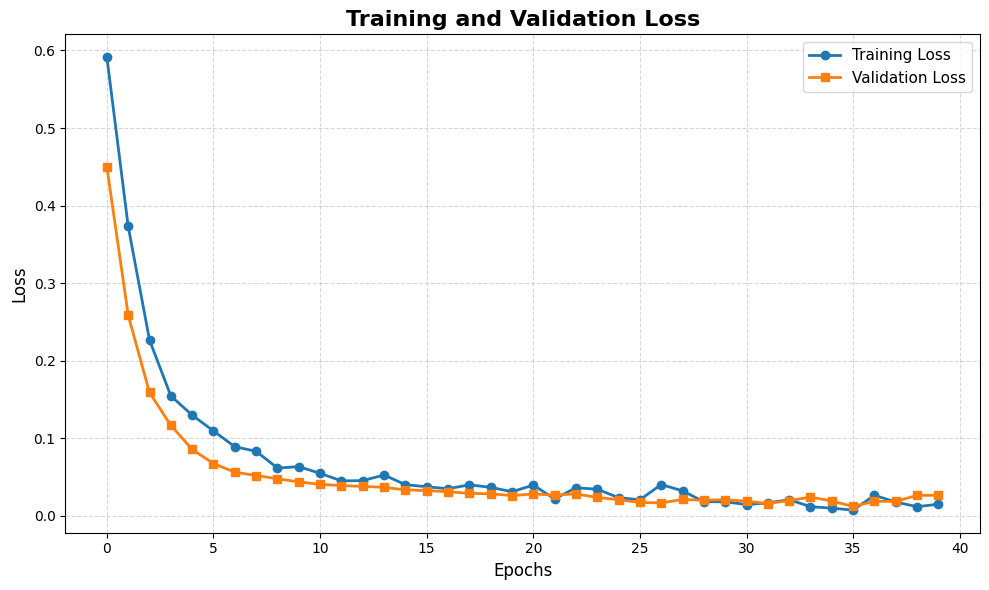

In [37]:
# Loss Graph
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    marker='o',
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    marker='s',
    linewidth=2,
    label='Validation Loss'
)

plt.title(
    'Training and Validation Loss',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

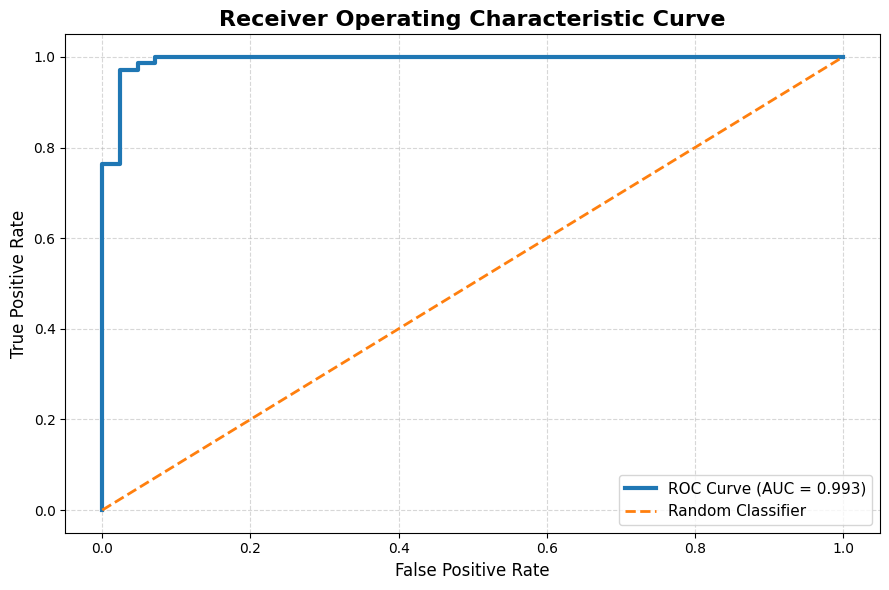

In [38]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

# Calculate AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(9, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'ROC Curve (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.title(
    'Receiver Operating Characteristic Curve',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [39]:
# Conclusion
print("Aishi De")
print("\nModel trained and tested successfully.")
print("The confusion matrix and accuracy show the classification performance.")


Aishi De

Model trained and tested successfully.
The confusion matrix and accuracy show the classification performance.
